In [1]:
# Had to read population data through an excel workbook
import geopandas
import pandas
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import os
from time import time
import numpy as np
from pprint import pprint

state_name = 'Maine'
state_abbrev = 'me'
state_num = 23
nDistricts = 2

# pop_total_denominator = 330759736
# totalDistricts = 435
# target = pop_total_denominator / totalDistricts
state_total_pop = 1362359
target = state_total_pop / nDistricts

shapefile_dir = '/home/idies/workspace/21cc/Data/Census/Shapefiles/TIGER/'
new_districts_dir = '/home/idies/workspace/21cc/raddick/ungerrymandering/new-districts/'
pl94_dir = '/home/idies/workspace/21cc/Data/Census/PL 94-171 2020/{0:}/'.format(state_abbrev)

district_color_cycle = ['black', 'red', 'green', 'orange', 'cyan', 'yellow', 'pink', 'gray', 'lime', 'navajowhite', 'cornflowerblue', 'darkseagreen', 'thistle', 'tomato', 'silver', 'blueviolet', 'olive', 'peru', 'dodgerblue']
district_color_cycle += district_color_cycle
district_color_cycle += district_color_cycle
the_legend_size = 16
the_annotation_size = 8


print('ok')


ok


# Get population data by tract

In [2]:
#df = pandas.read_csv(
s = time()    
geofiles = [pl94_dir+x for x in os.listdir(pl94_dir) if (('geo' in x) and (x[-3:] == '.pl'))]
    #geofiles.append([x for x in geofiles if x[0:2] == this_focus_state.lower()])
geo_df = pandas.DataFrame()

for thisfile in geofiles:
    print('\treading {0:}...'.format(thisfile))
    geo_df_i = pandas.read_csv(thisfile, sep='|', header=None, low_memory=False, encoding='ISO-8859-1')#, encoding='utf-8')
    geo_df = pandas.concat((geo_df, geo_df_i), axis=0)
    
print('renaming columns...')
column_names = []
column_names += ['FILEID', 'STUSAB', 'SUMLEV', 'GEOVAR', 'GEOCOMP', 'CHARITER', 'CIFSN', 'LOGRECNO', 'GEOID']
column_names += ['GEOCODE', 'REGION', 'DIVISION', 'STATE', 'STATENS', 'COUNTY', 'COUNTYCC', 'COUNTYNS']
column_names += ['COUSUB', 'COUSUBCC', 'COUSUBNS']
column_names += ['SUBMCD', 'SUBMDCC', 'SUBMCDNS', 'ESTATE', 'ESTATECC', 'ESTATENS']
column_names += ['CONCIT', 'CONCITCC', 'CONCITNS', 'PLACE','PLACECC', 'PLACENS']
column_names += ['TRACT', 'BLKGRP', 'BLOCK']
column_names += ['AIANHH', 'AIANHHLI', 'AIANHHFP', 'AIANHHCC', 'AIANHHNS', 'AITS', 'AITSFP', 'AITSCC', 'AITSNS']
column_names += ['TTRACT', 'TBLKGRP', 'ANRC', 'ANRCCC', 'ARNCNS']
column_names += ['CBSA', 'MEMI', 'CSA', 'METDIV']
column_names += ['NECTA', 'NMEMI', 'CNECTA', 'NECTADIV']
column_names += ['CBSAPCI', 'NECTAPCI', 'UA', 'UATYPE', 'UR']
column_names += ['CD116', 'CD118', 'CD119', 'CD120', 'CD121']
column_names += ['SLDU18', 'SLDU22', 'SLDU24', 'SLDU26', 'SLDU28']
column_names += ['SLDL18', 'SLDL22', 'SLDL24', 'SLDL26', 'SLDL28']
column_names += ['VTD', 'VTDI', 'ZCTA', 'SDELM', 'SDSEC', 'SDUNI', 'PUMA']
column_names += ['AREALAND', 'AREAWATER', 'BASENAME', 'NAME', 'FUNCSTAT', 'GCUNI']
column_names += ['POP100', 'HU100']
column_names += ['INTPTLAT', 'INTPTLON', 'LSADC', 'PARTFLAG', 'UGA']

geo_df.columns = column_names

print('\tTotal columns: {0:.0f}'.format(len(geo_df.columns)))
print('\tNamed columns: {0:.0f}'.format(len(column_names)))

geo_df = geo_df.set_index('GEOID')
tract_pop_df = geo_df[geo_df['SUMLEV'] == 140]
e = time()

print('Got populations of {0:,.0f} census tracts in {1:,.0f} seconds!'.format(len(tract_pop_df), e-s))


	reading /home/idies/workspace/21cc/Data/Census/PL 94-171 2020/me/megeo2020.pl...
renaming columns...
	Total columns: 97
	Named columns: 97
Got populations of 407 census tracts in 2 seconds!


# Get shapefiles

In [3]:
print('getting new districts...')
new_districts_df = pandas.read_csv(new_districts_dir+'new-districts-1-to-7.csv')

print('getting tracts...')
tracts_gdf = geopandas.read_file(shapefile_dir+'2020/TRACT/tl_2020_{0:02d}_tract.shp'.format(state_num))

tracts_gdf.loc[:, 'GEOID'] = tracts_gdf['GEOID'].apply(lambda x: '1400000US'+x)
tracts_gdf = tracts_gdf[tracts_gdf['GEOID'].apply(lambda x: '1400000US{0:02d}'.format(state_num) in x)]
tracts_gdf = tracts_gdf.set_index('GEOID')

new_districts_df = new_districts_df[new_districts_df['GEOID'].apply(lambda x: '1400000US{0:02d}'.format(state_num) in x)]
new_districts_df = new_districts_df.set_index('GEOID')

tracts_gdf = tracts_gdf.join(new_districts_df)
tracts_gdf = tracts_gdf[[x for x in tracts_gdf.columns if x != 'geometry']+['geometry']]

print('joining population data...')
tracts_gdf = tracts_gdf.join(tract_pop_df['POP100'])

print('getting original districts...')
cd119_gdf = geopandas.read_file(shapefile_dir+'2025/CD/tl_2025_{0:02d}_cd119.shp'.format(state_num))

print('getting places...')
place_gdf = geopandas.read_file(shapefile_dir+'2025/PLACE/tl_2025_{0:02d}_place.shp'.format(state_num))
place_gdf = place_gdf.set_index('GEOIDFQ')

print('getting water...')
s = time()
thefilelist = [shapefile_dir+'/2025/AREAWATER/{0:}/'.format(state_abbrev)+x for x in os.listdir(shapefile_dir+'/2025/AREAWATER/{0:}/'.format(state_abbrev)) if x[-4:] == '.shp']
water_gdf = geopandas.GeoDataFrame()
for i in range(0,len(thefilelist)):
    if ((np.mod(i, 10) == 0) | (i == len(thefilelist))):
        print('Reading areawater file {0:,.0f} of {1:,.0f}...'.format(i, len(thefilelist)))
    ggdf = geopandas.read_file(thefilelist[i])
    water_gdf = pandas.concat((water_gdf, ggdf), axis=0)
water_gdf.loc[:, 'HYDROID'] = water_gdf['HYDROID'].apply(lambda x: x.ljust(14, '0'))
water_gdf = water_gdf.set_index('HYDROID')
water_gdf.loc[:, 'INTPTLON'] = pandas.to_numeric(water_gdf['INTPTLON'])
water_gdf.loc[:, 'INTPTLAT'] = pandas.to_numeric(water_gdf['INTPTLAT'])
water_gdf = water_gdf.sort_values(by='AWATER', ascending=False)
# # print('changing crs...')
water_gdf = water_gdf.to_crs(tracts_gdf.crs)
e = time()
print('Read {0:,.0f} bodies of areawater in {1:} in {2:,.1f} seconds!'.format(len(water_gdf), state_name, e-s))    

print('Got districts for {0:,.0f} census tracts'.format(len(tracts_gdf)))


getting new districts...
getting tracts...
joining population data...
getting original districts...
getting places...
getting water...
Reading areawater file 0 of 16...
Reading areawater file 10 of 16...
Read 8,679 bodies of areawater in Maine in 1.3 seconds!
Got districts for 407 census tracts


/tmp/ipykernel_2170/4105396091.py:38: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  water_gdf.loc[:, 'INTPTLON'] = pandas.to_numeric(water_gdf['INTPTLON'])
/tmp/ipykernel_2170/4105396091.py:39: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  water_gdf.loc[:, 'INTPTLAT'] = pandas.to_numeric(water_gdf['INTPTLAT'])


In [4]:
# Fix water
show_water_gdf = geopandas.GeoDataFrame()
#excluded_gdf = geopandas.GeoDataFrame()

include_signs = []
include_signs += ['Atlantic Ocean','Casco Bay','Saco Bay','Penobscot Bay','W Penobscot Bay','Union River Bay','Fish Creek Bay','Western Bay','Bagaduce']  # NH Border to Ellsworth
include_signs += ['Gulf of Maine','Grand Manan Chnnl','Cobscook Bay','Moosabec Reach','Dennys Bay','Eastern Bay','Gouldsboro Bay','Whiting Bay','Narragaugus Bay','Pleasant Bay','Douglas Island Hbr','Southwest Cv','Mud Hole Chnnl','Little Kennebec Bay'] # Ellsworth to Eastport
show_water_gdf = pandas.concat((show_water_gdf, 
                              water_gdf[water_gdf['FULLNAME'].apply(
                                  lambda x: x in include_signs
                              )]))
unnamed_ocean_areas = []
unnamed_ocean_areas += ['11045603976000','11022172158650','11045603248400','11034075581300','11034075581500','11034075581400', '11034075583400','11030845898430','11045603248500','11045603235400','11019135564100']  # NH Border to Rockland
unnamed_ocean_areas += ['11036147355387','11090979827590','11016670023600','11022798770220','11036147355389','11046940458800','11046940457800','11046940457400','11046940457300','11016670023200','11016670023700'] # Rockland to Ellsworth
unnamed_ocean_areas += ['11015636130910','11090979827600','11015636130940','11015636130980','11083114369930','11015636131130','11015636130750','11015636125020','11015636130960','11015636130080']
show_water_gdf = pandas.concat((show_water_gdf, water_gdf[water_gdf.index.isin(unnamed_ocean_areas)]))

#excluded_gdf = pandas.concat((excluded_gdf, water_gdf[~water_gdf.index.isin(show_water_gdf.index.tolist())]))

show_water_gdf = show_water_gdf.sort_values(by='AWATER', ascending=False)
show_water_gdf = show_water_gdf.to_crs(water_gdf.crs)

# excluded_gdf = excluded_gdf.sort_values(by='AWATER', ascending=False)
# excluded_gdf = excluded_gdf.to_crs(water_gdf.crs)

print('ok')

ok


In [5]:
# xlim = [-68,-66.8] 
# ylim = [44.3,44.9]

# show_names = False
# nNames = 3

# print('plotting...')
# fig, ax = plt.subplots(1,1)
# ax.set_aspect('equal')

# #tracts_gdf.plot(ax=ax, color='none', edgecolor='gray')

# show_water_gdf.plot(ax=ax, color='blue')
# # excluded_gdf.plot(ax=ax, color='pink')

# # show_water_gdf[
# #     ((show_water_gdf['INTPTLON'].apply(lambda x: x >= xlim[0])) & (show_water_gdf['INTPTLON'].apply(lambda x: x <= xlim[1])))
# #     & (show_water_gdf['INTPTLAT'].apply(lambda y: y >= ylim[0])) & (show_water_gdf['INTPTLAT'].apply(lambda y: y <= ylim[1]))
# # ].plot(ax=ax, color='blue')

# # excluded_gdf[
# #     ((excluded_gdf['INTPTLON'].apply(lambda x: x >= xlim[0])) & (excluded_gdf['INTPTLON'].apply(lambda x: x <= xlim[1])))
# #     & (excluded_gdf['INTPTLAT'].apply(lambda y: y >= ylim[0])) & (excluded_gdf['INTPTLAT'].apply(lambda y: y <= ylim[1]))
# # ].plot(ax=ax, color='red')

# # ax.set_xlim(xlim)
# # ax.set_ylim(ylim)

# if (show_names):
#     for ix, thisrow in excluded_gdf[
#         ((excluded_gdf['INTPTLON'].apply(lambda x: x >= xlim[0])) & (excluded_gdf['INTPTLON'].apply(lambda x: x <= xlim[1])))
#         & (excluded_gdf['INTPTLAT'].apply(lambda y: y >= ylim[0])) & (excluded_gdf['INTPTLAT'].apply(lambda y: y <= ylim[1]))
#     ].head(nNames).sort_values(by='AWATER', ascending=False).iterrows():
#         if (thisrow['FULLNAME'] != None):
#             annotator = thisrow['FULLNAME']
#         else:
#             annotator = ix
#         print(annotator)
#         ax.annotate(annotator, (thisrow['INTPTLON'], thisrow['INTPTLAT']), (thisrow['INTPTLON'], thisrow['INTPTLAT']), 
#                    ha='center', backgroundcolor='white', size=6)

# plt.show()

# #print('ok')
# # Far South: xlim = [-70.8,-70.2] ; ylim = [42.85,43.4]
# # Portland to Rockland: xlim = [-70.4,-69.4] ; ylim = [43.4,44]
# # Rockland to Ellsworth: xlim = [-69.5,-68.35] ; ylim = [43.7,44.5]
# # Ellsworth to Eastport: xlim = [-69,-66.8] ; ylim = [43.5,44.9]


Done!


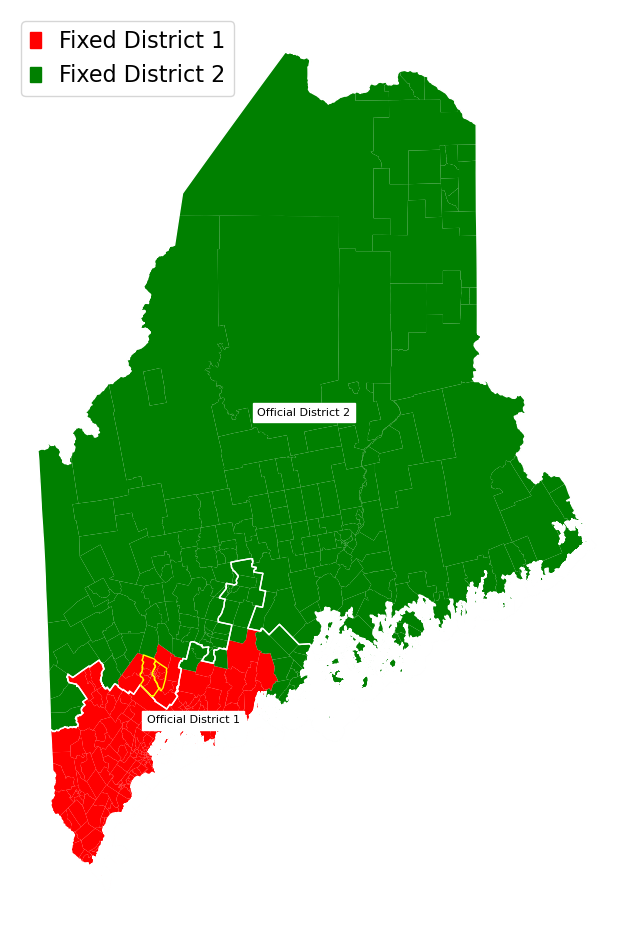

In [6]:
fig, ax = plt.subplots(1,1,figsize=(8,12))
ax.set_aspect('equal')

# xlim = [-70.85,-70.5]
# ylim = [42.85,43]

for i in range (1, nDistricts+1):
    tracts_gdf[tracts_gdf['new_district'] == i].plot(ax=ax, color=district_color_cycle[i])

legend_list = []
for i in range(1,nDistricts+1):
    #legend_list.append(mpatches.Patch(color=district_color_cycle[i], label='Fixed District {0:,.0f} (Pop {1:,.0f}, overshot = {2:,.0f})'.format(i, tracts_gdf[tracts_gdf['new_district'] == i]['POP100'].sum(), tracts_gdf[tracts_gdf['new_district'] == i]['POP100'].sum()-target)))
    legend_list.append(mpatches.Patch(color=district_color_cycle[i], label='Fixed District {0:,.0f}'.format(i)))
ax.legend(handles=legend_list, fontsize=the_legend_size, loc='upper left', handlelength=0.5)

# #target

cd119_gdf.plot(ax=ax, color='none', edgecolor='white')

for ix, thisrow in cd119_gdf.iterrows():
    centerpoint = [thisrow.geometry.centroid.x, thisrow.geometry.centroid.y]
    annotator = 'Official District {0:}'.format(thisrow['NAMELSAD'][-1])
    ax.annotate(annotator, centerpoint, 
                 color='black', backgroundcolor='white', ha='center', va='center', 
                 fontsize=the_annotation_size)

# Plot cities of Auburn/Lewiston
place_gdf[place_gdf['NAME'].isin(['Auburn','Lewiston'])].plot(ax=ax, color='none', edgecolor='yellow')
# for ix, thisrow in place_gdf[place_gdf['NAME'].isin(['Auburn','Lewiston'])].iterrows():
#     centerpoint = [thisrow.geometry.centroid.x, thisrow.geometry.centroid.y]
#     annotator = thisrow['NAME']
#     ax.annotate(annotator, centerpoint, 
#                  color='black', backgroundcolor='white', ha='center', va='center', 
#                  fontsize=the_annotation_size-2)


# Mask out water
show_water_gdf.plot(ax=ax, color='white', edgecolor='white')

plt.axis('off')

#plt.show()
plt.savefig('maps/maine-new-districts.png', format='png', dpi=300)
print('Done!')